In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "code":
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

DATA_DIR = BASE_DIR / "data" / "processed"
FIGURE_DIR = BASE_DIR / "figures"
RESULT_DIR = BASE_DIR / "results"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
# ============================================================
# ĐỌC TRAIN DATA
# ============================================================

price_train = pd.read_csv(
    DATA_DIR / "price_train.csv",
    parse_dates=["Date"]
)

return_train = pd.read_csv(
    DATA_DIR / "return_train.csv",
    parse_dates=["Date"]
)

price_train = (
    price_train
    .sort_values("Date")
    .reset_index(drop=True)
)

return_train = (
    return_train
    .sort_values("Date")
    .reset_index(drop=True)
)

print("Price Train:", price_train.shape)
print("Return Train:", return_train.shape)

print(
    price_train["Date"].min(),
    "->",
    price_train["Date"].max()
)

Price Train: (3871, 6)
Return Train: (3870, 7)
2010-01-04 00:00:00 -> 2024-12-31 00:00:00


In [4]:
def adf_test(series, name):
    """
    Augmented Dickey-Fuller test
    H0: chuỗi có unit root -> không dừng
    H1: chuỗi dừng
    """

    series = series.dropna()

    result = adfuller(
        series,
        autolag="AIC"
    )

    output = {
        "Series": name,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Used Lags": result[2],
        "N Observations": result[3],
        "Critical 1%": result[4]["1%"],
        "Critical 5%": result[4]["5%"],
        "Critical 10%": result[4]["10%"]
    }

    return output

In [5]:
adf_results = []

adf_results.append(
    adf_test(
        price_train["Close"],
        "Close"
    )
)

adf_results.append(
    adf_test(
        price_train["log_price"],
        "Log Price"
    )
)

adf_results.append(
    adf_test(
        return_train["log_return"],
        "Log Return"
    )
)

adf_table = pd.DataFrame(adf_results)

print(adf_table)

       Series  ADF Statistic   p-value  Used Lags  N Observations  \
0       Close      -1.974399  0.297910         25            3845   
1   Log Price      -1.986323  0.292602          0            3870   
2  Log Return     -61.019573  0.000000          0            3869   

   Critical 1%  Critical 5%  Critical 10%  
0    -3.432052    -2.862292     -2.567170  
1    -3.432041    -2.862287     -2.567168  
2    -3.432041    -2.862287     -2.567168  


In [6]:
adf_table.to_csv(
    RESULT_DIR / "adf_results.csv",
    index=False
)

In [7]:
price_train["diff_log_price"] = (
    price_train["log_price"].diff()
)

In [8]:
diff_result = adf_test(
    price_train["diff_log_price"],
    "First Difference Log Price"
)

print(
    pd.DataFrame([diff_result])
)

                       Series  ADF Statistic  p-value  Used Lags  \
0  First Difference Log Price     -61.019573      0.0          0   

   N Observations  Critical 1%  Critical 5%  Critical 10%  
0            3869    -3.432041    -2.862287     -2.567168  


<Figure size 1000x500 with 0 Axes>

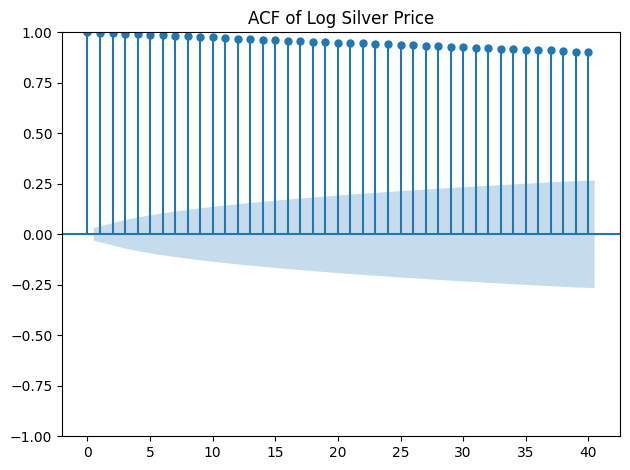

In [9]:
plt.figure(figsize=(10, 5))

plot_acf(
    price_train["log_price"].dropna(),
    lags=40
)

plt.title("ACF of Log Silver Price")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "07_acf_log_price.png",
    dpi=300
)

plt.show()

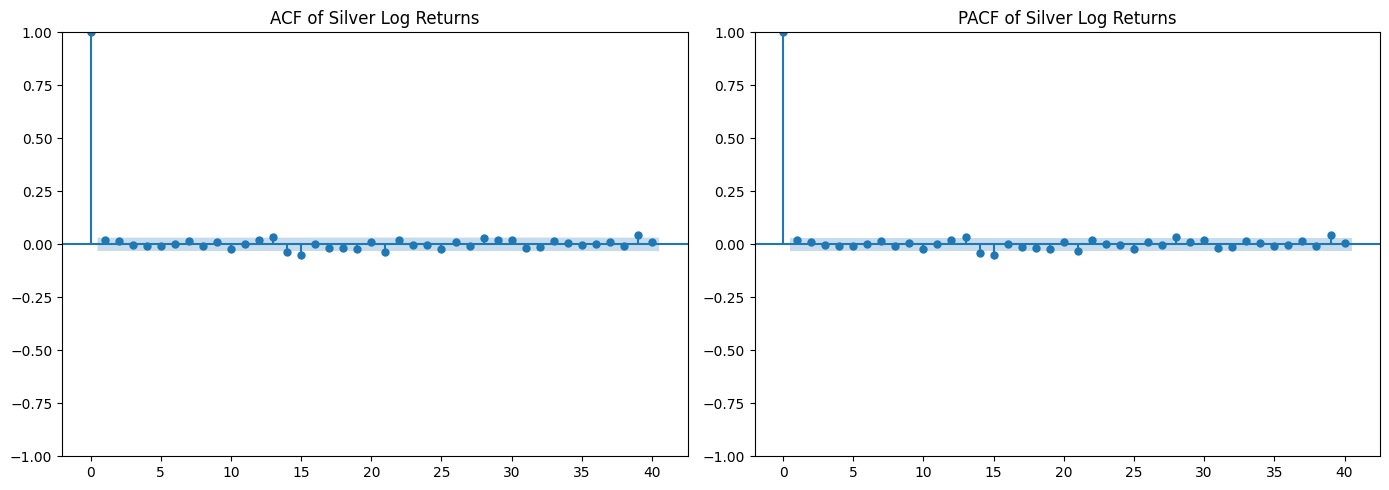

In [10]:
r = return_train["log_return"].dropna()

fig, ax = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

plot_acf(
    r,
    lags=40,
    ax=ax[0]
)

ax[0].set_title(
    "ACF of Silver Log Returns"
)

plot_pacf(
    r,
    lags=40,
    method="ywm",
    ax=ax[1]
)

ax[1].set_title(
    "PACF of Silver Log Returns"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "08_acf_pacf_returns.png",
    dpi=300
)

plt.show()

In [11]:
ljung_return = acorr_ljungbox(
    r,
    lags=[5, 10, 20],
    return_df=True
)

print(ljung_return)

      lb_stat  lb_pvalue
5    2.684702   0.748457
10   6.399315   0.780673
20  33.332333   0.031012


In [12]:
ljung_return.to_csv(
    RESULT_DIR / "ljung_box_returns.csv"
)

<Figure size 1000x500 with 0 Axes>

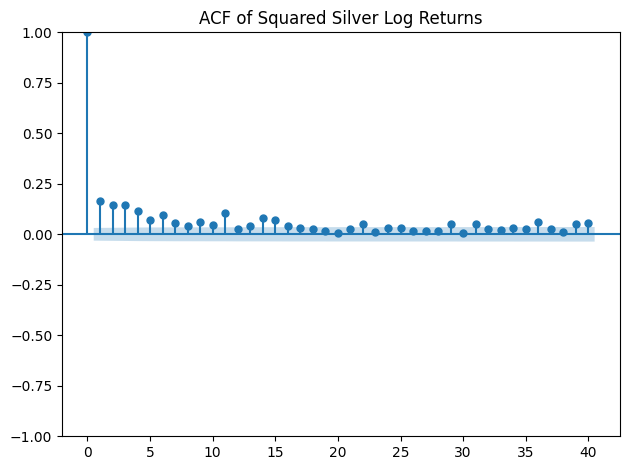

In [13]:
squared_return = r ** 2
plt.figure(figsize=(10, 5))

plot_acf(
    squared_return,
    lags=40
)

plt.title(
    "ACF of Squared Silver Log Returns"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "09_acf_squared_returns.png",
    dpi=300
)

plt.show()

In [14]:
ljung_squared = acorr_ljungbox(
    squared_return,
    lags=[5, 10, 20],
    return_df=True
)

print(ljung_squared)

       lb_stat     lb_pvalue
5   336.580903  1.354265e-70
10  414.324038  8.397180e-83
20  525.275473  1.470329e-98


In [15]:
ljung_squared.to_csv(
    RESULT_DIR / "ljung_box_squared_returns.csv"
)

In [16]:
arch_result = het_arch(
    r,
    nlags=10
)

arch_table = pd.DataFrame({
    "Statistic": [
        "LM Statistic",
        "LM p-value",
        "F Statistic",
        "F p-value"
    ],

    "Value": [
        arch_result[0],
        arch_result[1],
        arch_result[2],
        arch_result[3]
    ]
})

print(arch_table)

      Statistic         Value
0  LM Statistic  2.340310e+02
1    LM p-value  1.226183e-44
2   F Statistic  2.484261e+01
3     F p-value  4.251522e-46


In [17]:
arch_table.to_csv(
    RESULT_DIR / "arch_lm_results.csv",
    index=False
)

In [18]:
summary = pd.DataFrame({
    "Item": [
        "Price observations",
        "Return observations",
        "Train start",
        "Train end",
        "Mean return",
        "Std return",
        "Minimum return",
        "Maximum return"
    ],

    "Value": [
        len(price_train),
        len(return_train),
        price_train["Date"].min(),
        price_train["Date"].max(),
        r.mean(),
        r.std(),
        r.min(),
        r.max()
    ]
})

summary.to_csv(
    RESULT_DIR / "model_preparation_summary.csv",
    index=False
)

print(summary)

                  Item                Value
0   Price observations                 3871
1  Return observations                 3870
2          Train start  2010-01-04 00:00:00
3            Train end  2024-12-31 00:00:00
4          Mean return             0.013082
5           Std return             1.804976
6       Minimum return           -16.080396
7       Maximum return             8.512776
